In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta


from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (roc_auc_score,
                             root_mean_squared_error,
                             mean_absolute_error,
                             f1_score,
                             classification_report)

import optuna
import cupy as cp
from bs4 import BeautifulSoup

pd.set_option('display.max_columns', None)

Данные представляют собой список наиболее частых вопросов и ответов на них

In [2]:
data = pd.read_excel("data/FAQ_лайки_и_дизлайки.xlsx", sheet_name=[0, 1])
faq, faq_category = data[0], data[1]

In [3]:
display(faq.head())
faq.info()
display(faq.describe())
faq.isna().sum()

,id,category_id,question,e_question,answer,e_answer,region,visible,e_visible,deleted,status,e_order_number,order_number,status_title,updated,short_answer,e_short_answer,long_answer,e_long_answer,only_elm,app_type,code,meta_title,meta_description,meta_keywords,e_meta_title,e_meta_description,e_meta_keywords,r_yes,r_no,short_question,display_in_pso,title,descr,e_descr
0,4870,3.0,Как получить QR-код после вакцинации,Как получить QR-код после вакцинации,"<p>QR-код, подтверждающий прививку от COVID-19...","<p>QR-код, подтверждающий прививку от COVID-19...",NaN,Y,Y,N,P,20.0,20,Опубликовано,2022-03-11 00:00:00,"<p>QR-код, подтверждающий прививку от COVID-19...","<p>QR-код, подтверждающий прививку от COVID-19...","<p>QR-код, подтверждающий прививку от COVID-19...","<p>QR-код, подтверждающий прививку от COVID-19...",N,3,4870,NaN,NaN,NaN,NaN,NaN,NaN,15757,15095,NaN,Y,Как получить QR-код после вакцинации,NaN,NaN
1,2605,2317.0,Как получить справку о наличии или отсутствии ...,Как получить справку о наличии или отсутствии ...,"<p>Воспользуйтесь услугой <a href=""/16587/1/in...","<p>Воспользуйтесь услугой <a href=""/16587/1/in...",NaN,N,N,Y,P,5.0,5,Опубликовано,2018-08-10 14:07:23,"<p>Воспользуйтесь услугой <a href=""/16587/1/in...","<p>Воспользуйтесь услугой <a href=""/16587/1/in...",NaN,NaN,N,1,DELETED_2605,NaN,NaN,NaN,NaN,NaN,NaN,15071,11632,NaN,Y,NaN,NaN,NaN
2,2,1.0,Как подтвердить учётную запись через банк,Как подтвердить учётную запись через банк,<p>Это можно сделать онлайн за 10 минут &mdash...,<p>Это можно сделать онлайн за 10 минут &mdash...,0.0,Y,Y,N,P,2.0,2,Опубликовано,2022-03-21 00:00:00,<p>Это можно сделать онлайн за 10 минут &mdash...,<p>Это можно сделать онлайн за 10 минут &mdash...,NaN,NaN,N,3,2,NaN,NaN,NaN,NaN,NaN,NaN,4056,11624,NaN,Y,Как подтвердить учётную запись через банк,Способы подтвердить учётную запись онлайн и оф...,Способы подтвердить учётную запись онлайн и оф...
3,101032,1000170.0,Где узнать свой трудовой стаж,Где узнать свой трудовой стаж,"<ul class=""list-blue-dotted mt-8"">\n <li><a...","<ul class=""list-blue-dotted mt-8"">\n <li><a...",NaN,Y,Y,N,P,50.0,50,Опубликовано,2022-04-08 00:00:00,<p><span>Узнать стаж можно следующими способам...,<p><span>Узнать стаж можно следующими способам...,NaN,NaN,N,1,101032,NaN,NaN,NaN,NaN,NaN,NaN,11101,8436,NaN,Y,Где узнать свой трудовой стаж,NaN,NaN
4,100474,1000117.0,"Сколько действует QR-код вакцинированного, пер...","Сколько действует QR-код вакцинированного, пер...","<p style=""padding-left: 30px;""><strong>&bull;&...","<p style=""padding-left: 30px;""><strong>&bull;&...",NaN,N,N,Y,P,5.0,5,Опубликовано,2021-11-23 00:00:00,"<p style=""padding-left: 30px;""><strong>&bull;&...","<p style=""padding-left: 30px;""><strong>&bull;&...",<p><strong>С какого момента действует сертифик...,<p><strong>С какого момента действует сертифик...,N,3,100474,NaN,NaN,NaN,NaN,NaN,NaN,10637,6696,NaN,N,Срок действия QR-кодов и ПЦР-теста,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2451 entries, 0 to 2450
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  2451 non-null   int64         
 1   category_id         1618 non-null   float64       
 2   question            2451 non-null   object        
 3   e_question          2443 non-null   object        
 4   answer              2451 non-null   object        
 5   e_answer            2449 non-null   object        
 6   region              153 non-null    float64       
 7   visible             2451 non-null   object        
 8   e_visible           2451 non-null   object        
 9   deleted             2451 non-null   object        
 10  status              2451 non-null   object        
 11  e_order_number      2443 non-null   float64       
 12  order_number        2451 non-null   int64         
 13  status_title        2451 non-null   object      

,id,category_id,region,e_order_number,order_number,updated,app_type,r_yes,r_no,short_question
count,2451.000000,1.618000e+03,153.0,2443.000000,2451.000000,2451,2451.000000,2451.000000,2451.000000,0.0
mean,66899.940432,3.376082e+05,0.0,158.776095,164.099551,2021-04-11 11:11:00.196935680,1.127295,114.410445,102.910241,NaN
min,1.000000,1.000000e+00,0.0,0.000000,0.000000,2016-04-01 23:05:22,0.000000,0.000000,0.000000,NaN
25%,4023.500000,6.000000e+00,0.0,15.000000,15.000000,2021-05-24 00:00:00,1.000000,0.000000,0.000000,NaN
50%,100406.000000,2.308000e+03,0.0,65.000000,65.000000,2021-09-14 00:00:00,1.000000,4.000000,2.000000,NaN
75%,101018.500000,1.000139e+06,0.0,180.000000,180.000000,2022-03-02 00:00:00,1.000000,24.000000,19.000000,NaN
max,101710.000000,1.000370e+06,0.0,1908.000000,1908.000000,2022-04-21 00:00:00,7.000000,16899.000000,15095.000000,NaN
std,46568.233037,4.723434e+05,0.0,273.268659,287.954215,NaN,0.624102,797.213514,616.392889,NaN


id                       0
category_id            833
question                 0
e_question               8
answer                   0
e_answer                 2
region                2298
visible                  0
e_visible                0
deleted                  0
status                   0
e_order_number           8
order_number             0
status_title             0
updated                  0
short_answer           627
e_short_answer         627
long_answer           2033
e_long_answer         2033
only_elm                 0
app_type                 0
code                     0
meta_title            1858
meta_description      1878
meta_keywords         1886
e_meta_title          1859
e_meta_description    1879
e_meta_keywords       1887
r_yes                    0
r_no                     0
short_question        2451
display_in_pso           0
title                  328
descr                 2447
e_descr               2447
dtype: int64

In [4]:
val_count_col = ["region", "visible", "e_visible", "deleted", "status", "status_title"]
for col in val_count_col:
    display(faq[col].value_counts())


region
0.0    153
Name: count, dtype: int64

visible
Y    1666
N     785
Name: count, dtype: int64

e_visible
Y    1666
N     785
Name: count, dtype: int64

deleted
N    1730
Y     721
Name: count, dtype: int64

status
P    2380
E      61
N      10
Name: count, dtype: int64

status_title
Опубликовано                  2387
Редактирование                  49
Новая запись                     9
Готово к публикации              5
Отправлено на согласование       1
Name: count, dtype: int64

In [5]:
faq = faq.join(faq_category[["id", "title"]].set_index("id"),
               how="left",
               on="category_id",
               rsuffix="_category")

faq["category_id"] = faq["category_id"].fillna(-1)
faq["title_category"] = faq["title_category"].fillna("Другое")

actual_faq = faq[(faq["visible"] =="Y") &
                 (faq["deleted"] == "N") &
                 (faq["status_title"] == "Опубликовано")].copy()

In [6]:
actual_faq.head()

,id,category_id,question,e_question,answer,e_answer,region,visible,e_visible,deleted,status,e_order_number,order_number,status_title,updated,short_answer,e_short_answer,long_answer,e_long_answer,only_elm,app_type,code,meta_title,meta_description,meta_keywords,e_meta_title,e_meta_description,e_meta_keywords,r_yes,r_no,short_question,display_in_pso,title,descr,e_descr,title_category
0,4870,3.0,Как получить QR-код после вакцинации,Как получить QR-код после вакцинации,"<p>QR-код, подтверждающий прививку от COVID-19...","<p>QR-код, подтверждающий прививку от COVID-19...",NaN,Y,Y,N,P,20.0,20,Опубликовано,2022-03-11,"<p>QR-код, подтверждающий прививку от COVID-19...","<p>QR-код, подтверждающий прививку от COVID-19...","<p>QR-код, подтверждающий прививку от COVID-19...","<p>QR-код, подтверждающий прививку от COVID-19...",N,3,4870,NaN,NaN,NaN,NaN,NaN,NaN,15757,15095,NaN,Y,Как получить QR-код после вакцинации,NaN,NaN,Здоровье
2,2,1.0,Как подтвердить учётную запись через банк,Как подтвердить учётную запись через банк,<p>Это можно сделать онлайн за 10 минут &mdash...,<p>Это можно сделать онлайн за 10 минут &mdash...,0.0,Y,Y,N,P,2.0,2,Опубликовано,2022-03-21,<p>Это можно сделать онлайн за 10 минут &mdash...,<p>Это можно сделать онлайн за 10 минут &mdash...,NaN,NaN,N,3,2,NaN,NaN,NaN,NaN,NaN,NaN,4056,11624,NaN,Y,Как подтвердить учётную запись через банк,Способы подтвердить учётную запись онлайн и оф...,Способы подтвердить учётную запись онлайн и оф...,Вход и регистрация
3,101032,1000170.0,Где узнать свой трудовой стаж,Где узнать свой трудовой стаж,"<ul class=""list-blue-dotted mt-8"">\n <li><a...","<ul class=""list-blue-dotted mt-8"">\n <li><a...",NaN,Y,Y,N,P,50.0,50,Опубликовано,2022-04-08,<p><span>Узнать стаж можно следующими способам...,<p><span>Узнать стаж можно следующими способам...,NaN,NaN,N,1,101032,NaN,NaN,NaN,NaN,NaN,NaN,11101,8436,NaN,Y,Где узнать свой трудовой стаж,NaN,NaN,Пенсия
5,1,20.0,Регистрация на Госуслугах,Регистрация на Госуслугах,<p><span>Для получения доступа ко всем услугам...,<p><span>Для получения доступа ко всем услугам...,0.0,Y,Y,N,P,3.0,3,Опубликовано,2021-11-26,<p><span>Для получения доступа ко всем услугам...,<p><span>Для получения доступа ко всем услугам...,NaN,NaN,N,3,1,Как подтвердить учётную запись в центре обслуж...,Куда идти и какие документы взять,"центр обслуживания, учётная запись, подтвердит...",Как подтвердить учётную запись в центре обслуж...,Куда идти и какие документы взять,"центр обслуживания, учётная запись, подтвердит...",6568,5686,NaN,Y,Регистрация на Госуслугах,"Способы регистрации: через банк, на портале ил...","Способы регистрации: через банк, на портале ил...",Регистрация
6,40,13.0,Зачем нужен личный кабинет,Зачем нужен личный кабинет,"<p>В&nbsp;<a href=""https://lk.gosuslugi.ru/"">л...","<p>В&nbsp;<a href=""https://lk.gosuslugi.ru/"">л...",0.0,Y,Y,N,P,0.0,0,Опубликовано,2021-09-07,"<p>В <a href=""https://lk.gosuslugi.ru/"">личном...","<p>В <a href=""https://lk.gosuslugi.ru/"">личном...",NaN,NaN,N,1,40,NaN,NaN,NaN,NaN,NaN,NaN,16899,5118,NaN,N,Зачем нужен личный кабинет,NaN,NaN,Личный кабинет


## Расчет метрик

### 1. Полезность ответа

Метрика показывает качество ответа на вопрос, основываясь на оценках пользователей.

In [7]:
actual_faq["helpfulness_score"] = (actual_faq["r_yes"] / (actual_faq["r_yes"] + actual_faq["r_no"])).fillna(0)

helpfulness_by_cat = actual_faq.groupby("title_category", as_index=False).agg(
                                        helpfulness_score=("helpfulness_score", "mean"),
                                        category_id=("category_id", "first"),
                                        count=("id", "count"))
helpfulness_by_cat

,title_category,helpfulness_score,category_id,count
0,Автовладельцам,0.430339,2.0,72
1,Алименты,0.692492,1000104.0,1
2,Архивные справки,0.301887,2318.0,1
3,Безопасность и правопорядок,0.447206,2310.0,5
4,Водительское удостоверение,0.303797,2063.0,1
...,...,...,...,...
109,Центры обслуживания,0.573171,16.0,1
110,Что делать при коронавирусе,0.490390,4262.0,6
111,Штрафы,0.771058,2078.0,1
112,Электронный европротокол,0.250000,4122.0,1


### 2. Актуальность ответа

Метрика предназначена для оценки актуальности ответа на вопрос.

In [8]:
actual_faq["updated"].max()

Timestamp('2022-04-21 00:00:00')

Так как самая последняя дата обновления была 2022 году и чтобы рассчет метрики был коректен. Представим что мы сейчас 2022 году.

In [9]:
fake_date = datetime(2022, 1, 29)
date_year_ago = fake_date - timedelta(365)

# обновлен ли ответ в течение года
actual_faq["updated_in_year"] = actual_faq["updated"] >= date_year_ago

In [10]:
updated_in_year_by_cat = actual_faq.groupby("title_category", as_index=False).agg(
                                            actual_score=("updated_in_year", "mean"),
                                            category_id=("category_id", "first"),
                                            count=("id", "count"))

updated_in_year_by_cat

,title_category,actual_score,category_id,count
0,Автовладельцам,0.861111,2.0,72
1,Алименты,1.000000,1000104.0,1
2,Архивные справки,1.000000,2318.0,1
3,Безопасность и правопорядок,1.000000,2310.0,5
4,Водительское удостоверение,1.000000,2063.0,1
...,...,...,...,...
109,Центры обслуживания,1.000000,16.0,1
110,Что делать при коронавирусе,1.000000,4262.0,6
111,Штрафы,1.000000,2078.0,1
112,Электронный европротокол,1.000000,4122.0,1


Также можно сделать для 7 дней, 30 дней и тд.

### 3. Покрытие по категориям

Метрика нужна для понимая какие улуги имеют достаточное FAQ, а какие нет.

In [11]:
actual_faq_count = actual_faq.groupby("title_category", as_index=False).size()
all_category = faq_category[["id", "title"]]

covarage_faq = all_category.merge(
    actual_faq_count,
    how="left",
    left_on="title",
    right_on="title_category"
)

covarage_faq["size"] = covarage_faq["size"].fillna(0)
covarage_faq["is_covered"] = covarage_faq["size"] >= 5
covarage_faq

,id,title,title_category,size,is_covered
0,3103,МП Госуслуги Бизнес Главная для администратора,NaN,0.0,False
1,4883,Единый день голосования 2021,NaN,0.0,False
2,1000298,Вопросы о мерах социальной защиты в личном каб...,NaN,0.0,False
3,1000237,Вход и регистрация,Вход и регистрация,11.0,True
4,1000292,Временная регистрация,NaN,0.0,False
...,...,...,...,...,...
430,1000187,Обжалование автоштрафов,NaN,0.0,False
431,1000297,Регистрация прибывающих,Регистрация прибывающих,2.0,False
432,1000368,Частные охранные услуги,NaN,0.0,False
433,1000274,Покупка и продажа автомобиля,Покупка и продажа автомобиля,1.0,False


### 4. Полнота содержания

С помощью данном метрики можно понять долю заполненых FAQ для услуг.

In [12]:
actual_faq["is_complete"] = ((actual_faq[["question", "answer", "short_answer"]].notna().all(axis=1)) & 
                             (actual_faq["category_id"] != -1))

complete_by_cat = actual_faq.groupby("title_category", as_index=False).agg(
                                     complete_score=("is_complete", "mean"),
                                     category_id=("category_id", "first"),
                                     count=("id", "count"))

complete_by_cat

,title_category,complete_score,category_id,count
0,Автовладельцам,0.875000,2.0,72
1,Алименты,1.000000,1000104.0,1
2,Архивные справки,1.000000,2318.0,1
3,Безопасность и правопорядок,1.000000,2310.0,5
4,Водительское удостоверение,1.000000,2063.0,1
...,...,...,...,...
109,Центры обслуживания,1.000000,16.0,1
110,Что делать при коронавирусе,1.000000,4262.0,6
111,Штрафы,1.000000,2078.0,1
112,Электронный европротокол,1.000000,4122.0,1


## Визуализация

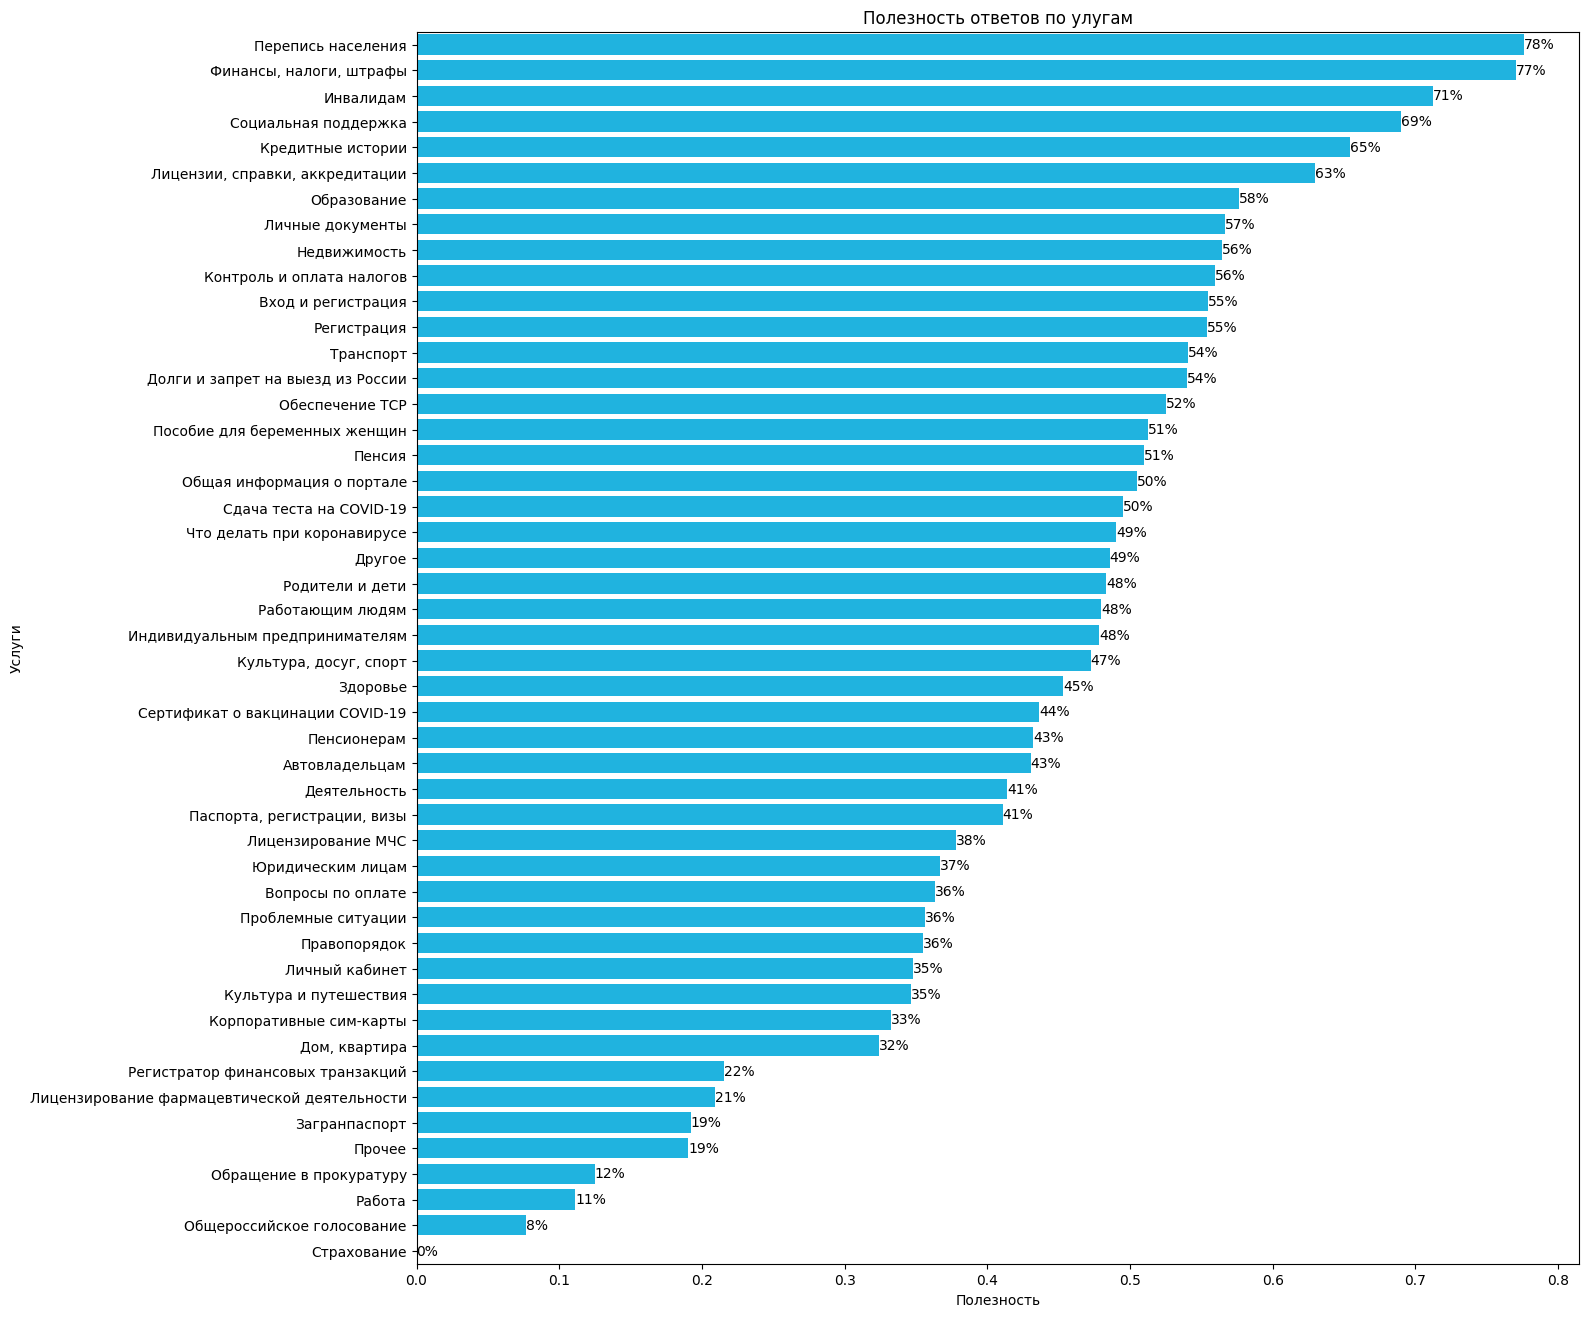

In [13]:
plt.figure(figsize=(15, 16))

plt_helpfulness = helpfulness_by_cat[helpfulness_by_cat["count"] > 5].sort_values(["helpfulness_score"], ascending=False)

ax = sns.barplot(data=plt_helpfulness,
                 x="helpfulness_score",
                 y="title_category",
                 color="#00C4FF")
ax.bar_label(ax.containers[0], fontsize=10, fmt=lambda x: f"{x*100:.0f}%")
plt.title("Полезность ответов по улугам")
plt.xlabel("Полезность")
plt.ylabel("Услуги")
plt.show()

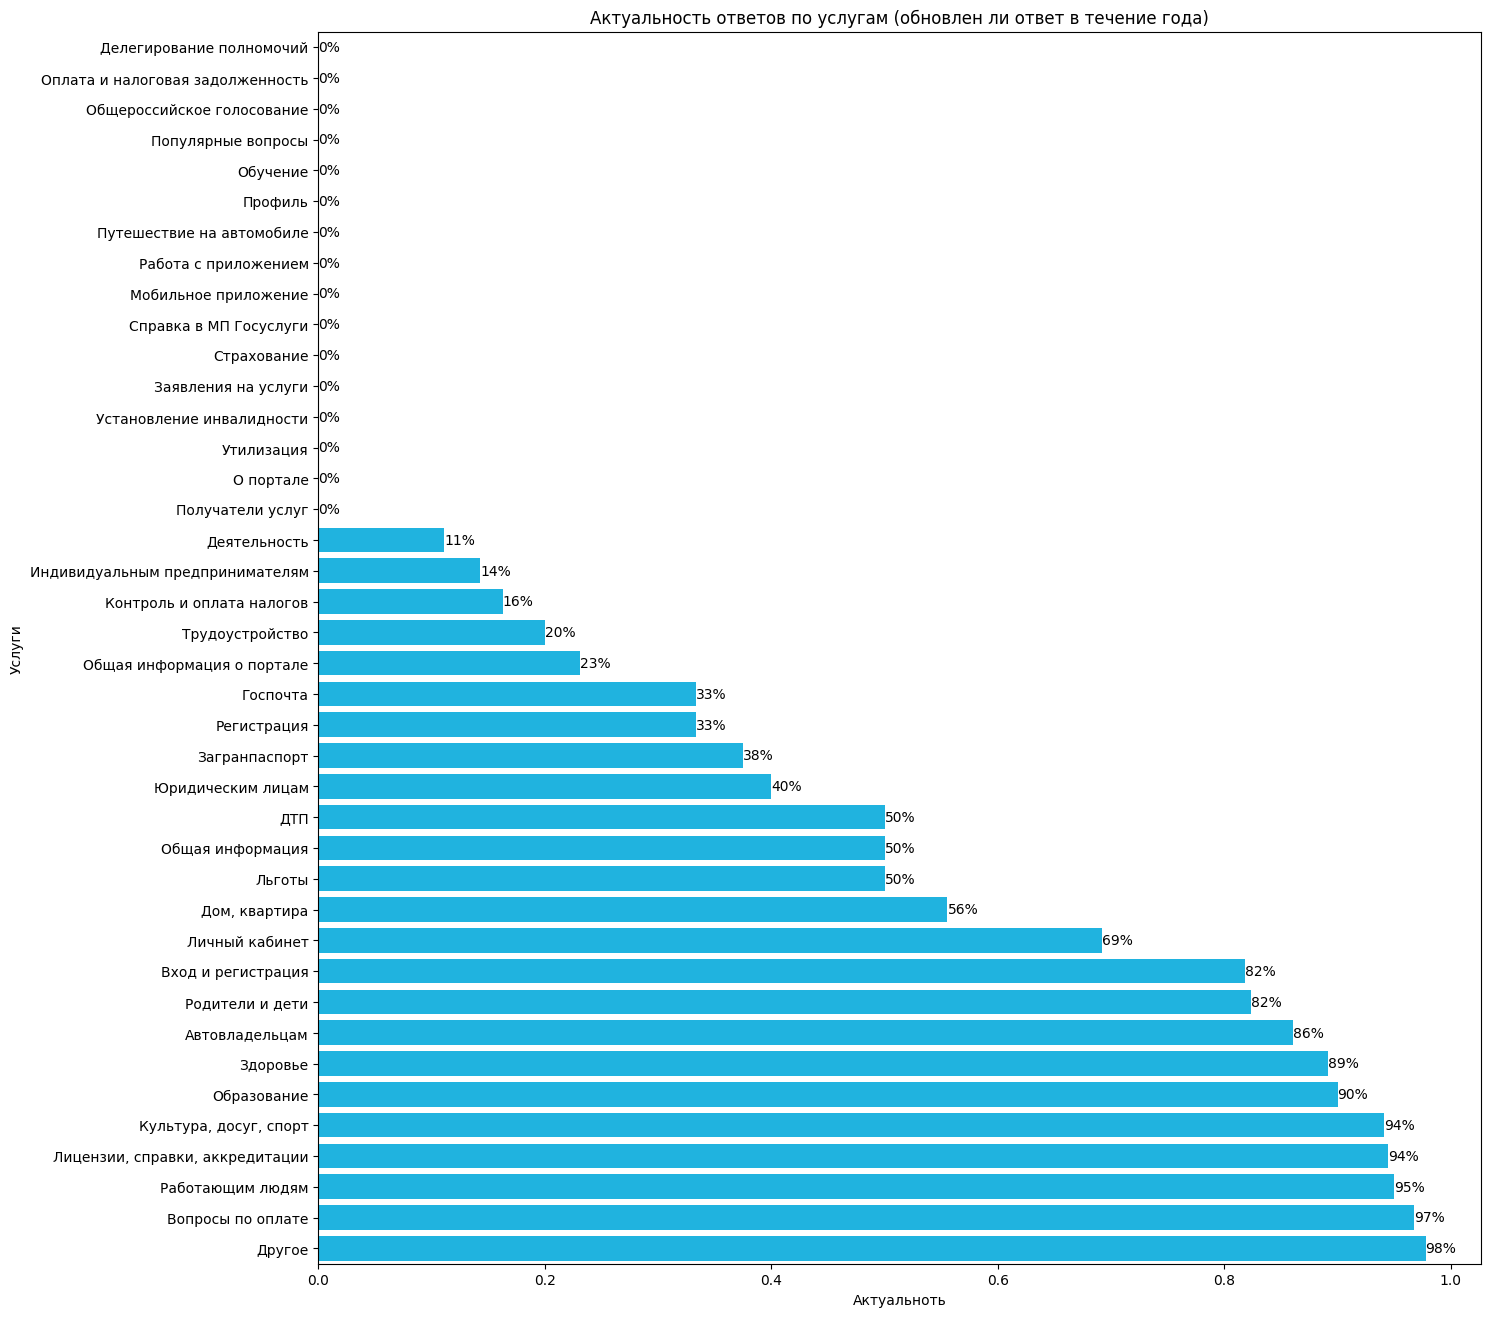

In [14]:
plt.figure(figsize=(15, 16))

plt_updated = updated_in_year_by_cat.sort_values(["actual_score"])
plt_updated = plt_updated[plt_updated["actual_score"] < 1]

ax = sns.barplot(data=plt_updated,
                 x="actual_score",
                 y="title_category",
                 color="#00C4FF")
ax.bar_label(ax.containers[0], fontsize=10, fmt=lambda x: f"{x*100:.0f}%")
plt.title("Актуальность ответов по услугам (обновлен ли ответ в течение года)")
plt.xlabel("Актуальноть")
plt.ylabel("Услуги")
plt.show()

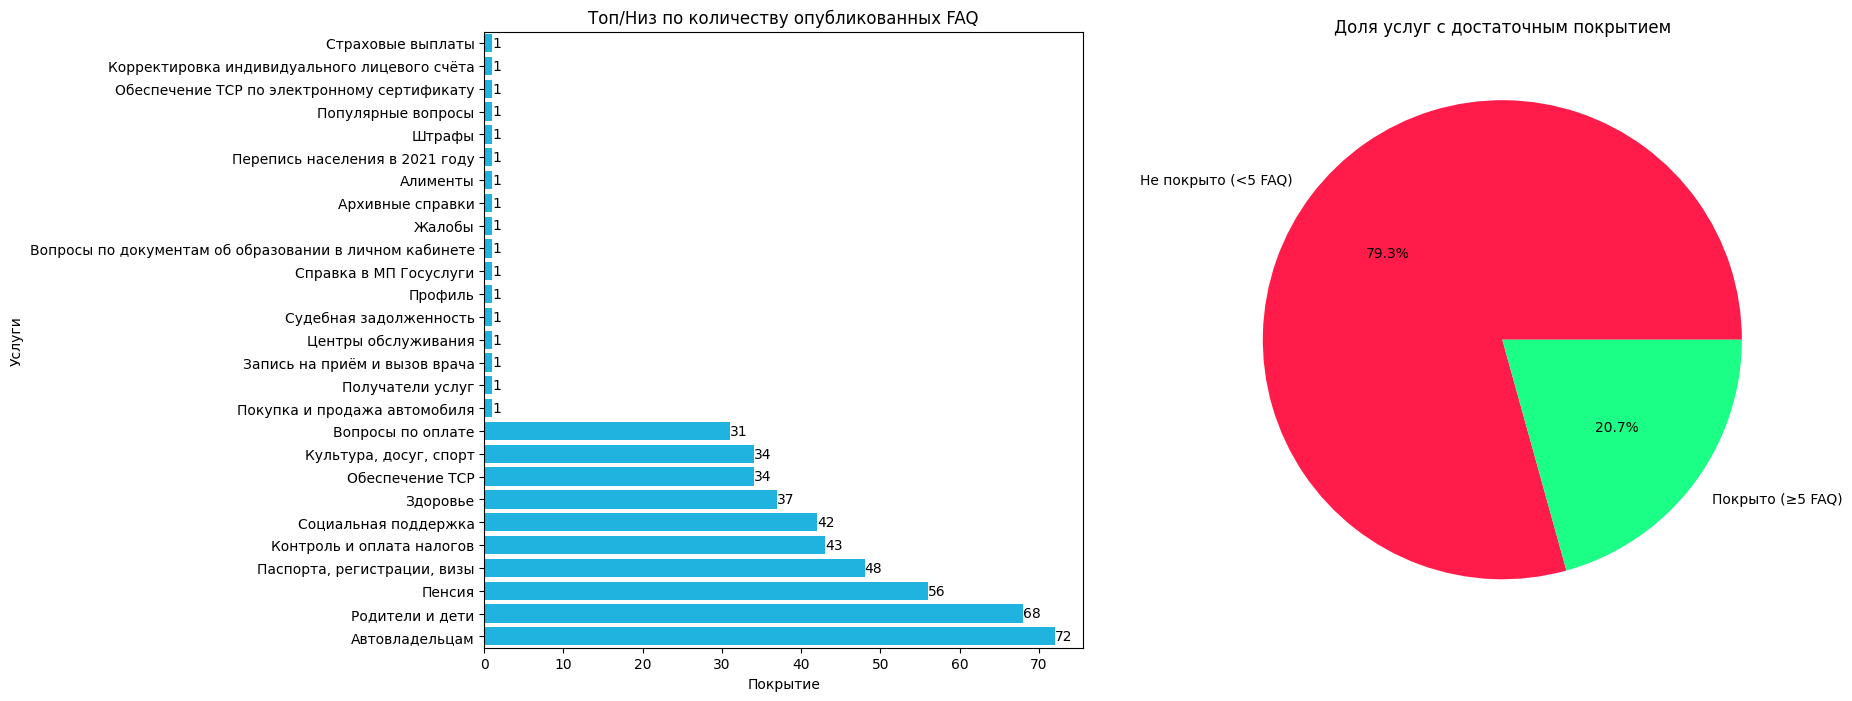

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(17, 8))


covered = covarage_faq[covarage_faq["size"] > 0]
top_bottom = pd.concat([
    covered.sort_values("size", ascending=False).head(20),
    covered.sort_values("size").head(20)
])

coverage_counts = covarage_faq["is_covered"].value_counts()


sns.barplot(data=top_bottom.sort_values("size"),
            x="size",
            y="title",
            color="#00C4FF",
            ax=ax[0])
ax[0].set_title("Топ/Низ по количеству опубликованных FAQ")
ax[0].bar_label(ax[0].containers[0], fontsize=10)
ax[0].set_xlabel("Покрытие")
ax[0].set_ylabel("Услуги")

ax[1].pie(
    coverage_counts,
    labels=["Не покрыто (<5 FAQ)", "Покрыто (≥5 FAQ)"],
    autopct="%1.1f%%",
    colors=["#FF1C4A", "#1CFF87"])
ax[1].set_title("Доля услуг с достаточным покрытием")
plt.show()

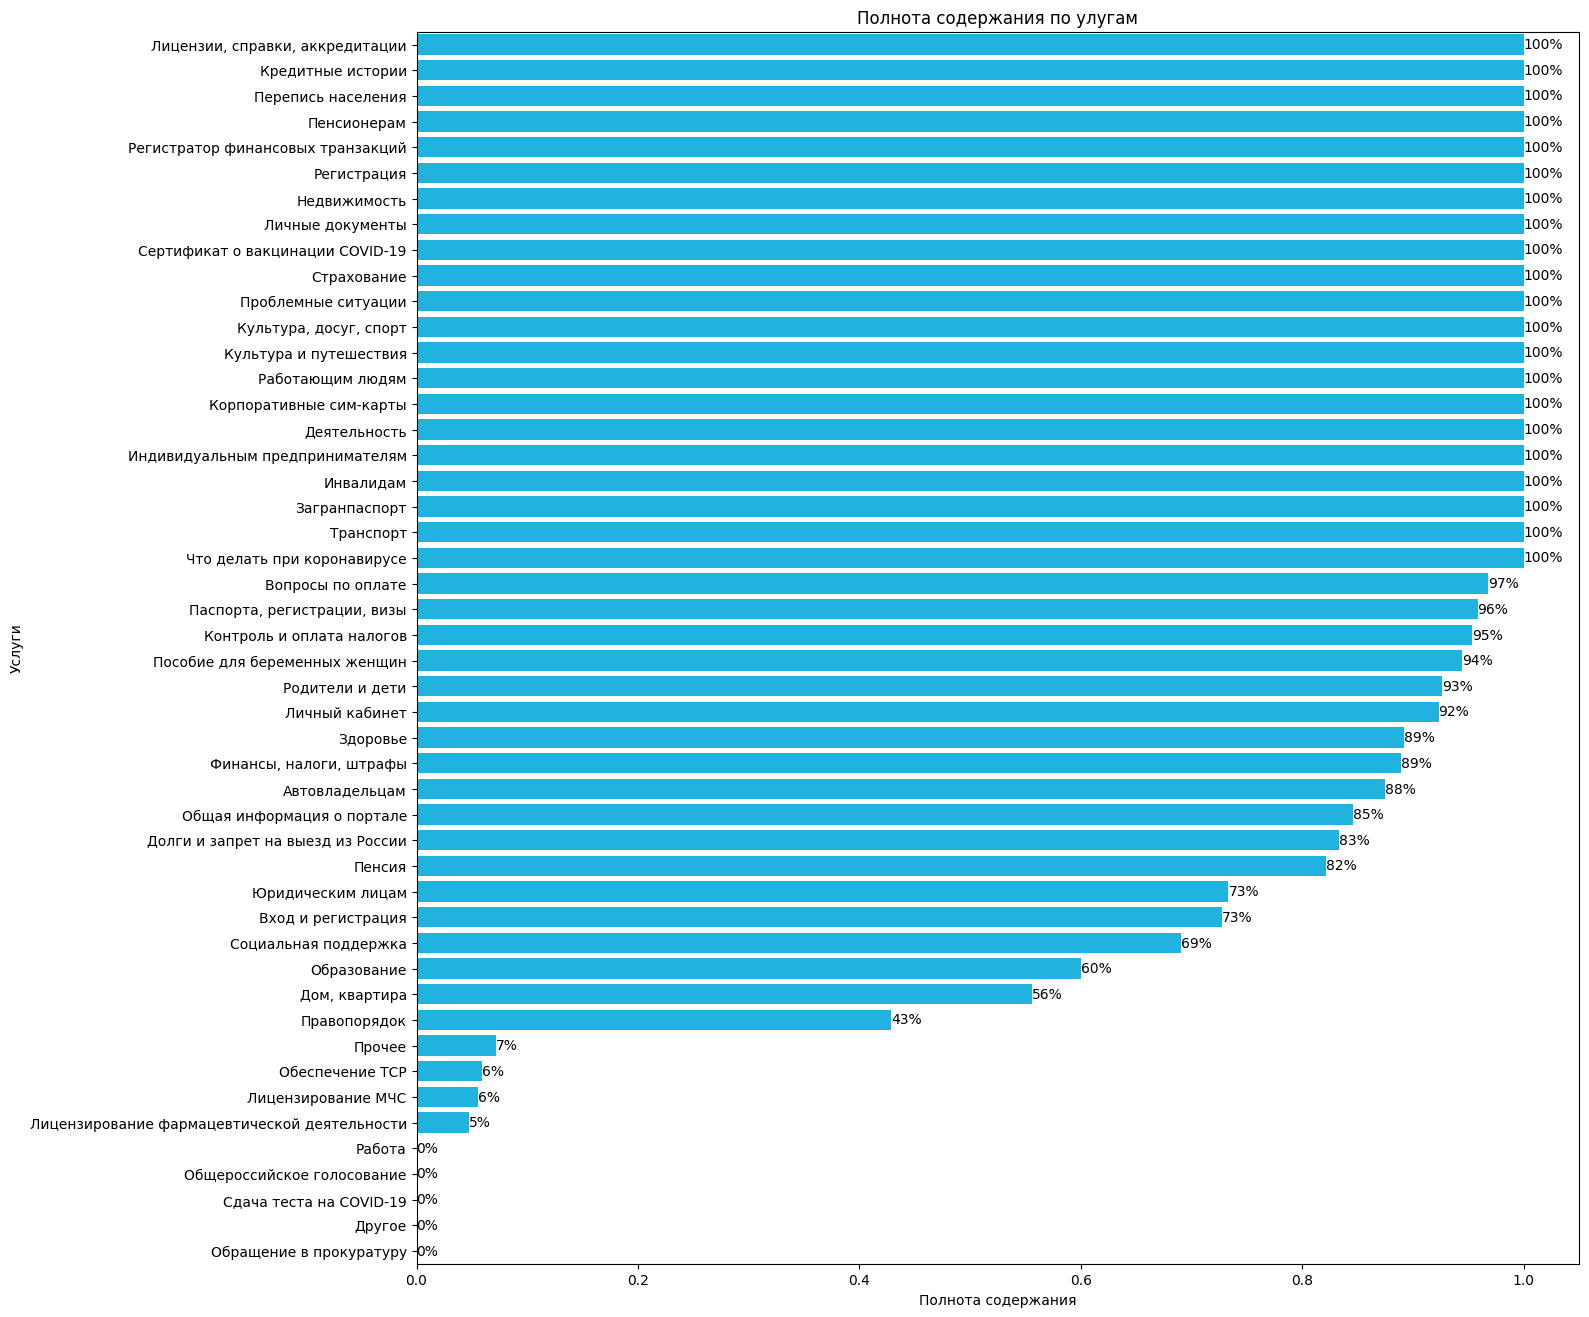

In [16]:
plt.figure(figsize=(15, 16))

plt_complete = complete_by_cat[complete_by_cat["count"] > 5].sort_values(["complete_score"], ascending=False)

ax = sns.barplot(data=plt_complete,
                 x="complete_score",
                 y="title_category",
                 color="#00C4FF")
ax.bar_label(ax.containers[0], fontsize=10, fmt=lambda x: f"{x*100:.0f}%")
plt.title("Полнота содержания по улугам")
plt.xlabel("Полнота содержания")
plt.ylabel("Услуги")
plt.show()

## Задачи предсказания

### 1. Предсказывать helpfulness_score

Цель в предсказании полезности ответа еще до публикации, чтобы заранее определить качество ответов.

In [17]:
display(faq.head())
faq.info()
display(faq.describe())
faq.isna().sum()

,id,category_id,question,e_question,answer,e_answer,region,visible,e_visible,deleted,status,e_order_number,order_number,status_title,updated,short_answer,e_short_answer,long_answer,e_long_answer,only_elm,app_type,code,meta_title,meta_description,meta_keywords,e_meta_title,e_meta_description,e_meta_keywords,r_yes,r_no,short_question,display_in_pso,title,descr,e_descr,title_category
0,4870,3.0,Как получить QR-код после вакцинации,Как получить QR-код после вакцинации,"<p>QR-код, подтверждающий прививку от COVID-19...","<p>QR-код, подтверждающий прививку от COVID-19...",NaN,Y,Y,N,P,20.0,20,Опубликовано,2022-03-11 00:00:00,"<p>QR-код, подтверждающий прививку от COVID-19...","<p>QR-код, подтверждающий прививку от COVID-19...","<p>QR-код, подтверждающий прививку от COVID-19...","<p>QR-код, подтверждающий прививку от COVID-19...",N,3,4870,NaN,NaN,NaN,NaN,NaN,NaN,15757,15095,NaN,Y,Как получить QR-код после вакцинации,NaN,NaN,Здоровье
1,2605,2317.0,Как получить справку о наличии или отсутствии ...,Как получить справку о наличии или отсутствии ...,"<p>Воспользуйтесь услугой <a href=""/16587/1/in...","<p>Воспользуйтесь услугой <a href=""/16587/1/in...",NaN,N,N,Y,P,5.0,5,Опубликовано,2018-08-10 14:07:23,"<p>Воспользуйтесь услугой <a href=""/16587/1/in...","<p>Воспользуйтесь услугой <a href=""/16587/1/in...",NaN,NaN,N,1,DELETED_2605,NaN,NaN,NaN,NaN,NaN,NaN,15071,11632,NaN,Y,NaN,NaN,NaN,"Лицензии, справки, аккредитации"
2,2,1.0,Как подтвердить учётную запись через банк,Как подтвердить учётную запись через банк,<p>Это можно сделать онлайн за 10 минут &mdash...,<p>Это можно сделать онлайн за 10 минут &mdash...,0.0,Y,Y,N,P,2.0,2,Опубликовано,2022-03-21 00:00:00,<p>Это можно сделать онлайн за 10 минут &mdash...,<p>Это можно сделать онлайн за 10 минут &mdash...,NaN,NaN,N,3,2,NaN,NaN,NaN,NaN,NaN,NaN,4056,11624,NaN,Y,Как подтвердить учётную запись через банк,Способы подтвердить учётную запись онлайн и оф...,Способы подтвердить учётную запись онлайн и оф...,Вход и регистрация
3,101032,1000170.0,Где узнать свой трудовой стаж,Где узнать свой трудовой стаж,"<ul class=""list-blue-dotted mt-8"">\n <li><a...","<ul class=""list-blue-dotted mt-8"">\n <li><a...",NaN,Y,Y,N,P,50.0,50,Опубликовано,2022-04-08 00:00:00,<p><span>Узнать стаж можно следующими способам...,<p><span>Узнать стаж можно следующими способам...,NaN,NaN,N,1,101032,NaN,NaN,NaN,NaN,NaN,NaN,11101,8436,NaN,Y,Где узнать свой трудовой стаж,NaN,NaN,Пенсия
4,100474,1000117.0,"Сколько действует QR-код вакцинированного, пер...","Сколько действует QR-код вакцинированного, пер...","<p style=""padding-left: 30px;""><strong>&bull;&...","<p style=""padding-left: 30px;""><strong>&bull;&...",NaN,N,N,Y,P,5.0,5,Опубликовано,2021-11-23 00:00:00,"<p style=""padding-left: 30px;""><strong>&bull;&...","<p style=""padding-left: 30px;""><strong>&bull;&...",<p><strong>С какого момента действует сертифик...,<p><strong>С какого момента действует сертифик...,N,3,100474,NaN,NaN,NaN,NaN,NaN,NaN,10637,6696,NaN,N,Срок действия QR-кодов и ПЦР-теста,NaN,NaN,Сертификат о вакцинации COVID-19


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2451 entries, 0 to 2450
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  2451 non-null   int64         
 1   category_id         2451 non-null   float64       
 2   question            2451 non-null   object        
 3   e_question          2443 non-null   object        
 4   answer              2451 non-null   object        
 5   e_answer            2449 non-null   object        
 6   region              153 non-null    float64       
 7   visible             2451 non-null   object        
 8   e_visible           2451 non-null   object        
 9   deleted             2451 non-null   object        
 10  status              2451 non-null   object        
 11  e_order_number      2443 non-null   float64       
 12  order_number        2451 non-null   int64         
 13  status_title        2451 non-null   object      

,id,category_id,region,e_order_number,order_number,updated,app_type,r_yes,r_no,short_question
count,2451.000000,2.451000e+03,153.0,2443.000000,2451.000000,2451,2451.000000,2451.000000,2451.000000,0.0
mean,66899.940432,2.228679e+05,0.0,158.776095,164.099551,2021-04-11 11:11:00.196935680,1.127295,114.410445,102.910241,NaN
min,1.000000,-1.000000e+00,0.0,0.000000,0.000000,2016-04-01 23:05:22,0.000000,0.000000,0.000000,NaN
25%,4023.500000,-1.000000e+00,0.0,15.000000,15.000000,2021-05-24 00:00:00,1.000000,0.000000,0.000000,NaN
50%,100406.000000,6.000000e+00,0.0,65.000000,65.000000,2021-09-14 00:00:00,1.000000,4.000000,2.000000,NaN
75%,101018.500000,4.242000e+03,0.0,180.000000,180.000000,2022-03-02 00:00:00,1.000000,24.000000,19.000000,NaN
max,101710.000000,1.000370e+06,0.0,1908.000000,1908.000000,2022-04-21 00:00:00,7.000000,16899.000000,15095.000000,NaN
std,46568.233037,4.157330e+05,0.0,273.268659,287.954215,NaN,0.624102,797.213514,616.392889,NaN


id                       0
category_id              0
question                 0
e_question               8
answer                   0
e_answer                 2
region                2298
visible                  0
e_visible                0
deleted                  0
status                   0
e_order_number           8
order_number             0
status_title             0
updated                  0
short_answer           627
e_short_answer         627
long_answer           2033
e_long_answer         2033
only_elm                 0
app_type                 0
code                     0
meta_title            1858
meta_description      1878
meta_keywords         1886
e_meta_title          1859
e_meta_description    1879
e_meta_keywords       1887
r_yes                    0
r_no                     0
short_question        2451
display_in_pso           0
title                  328
descr                 2447
e_descr               2447
title_category           0
dtype: int64

In [18]:
def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = text.lower()
    return text.strip()

In [21]:
drop_col = ["id", "region", "meta_title",
            "meta_description", "meta_keywords","e_meta_title",
            "e_meta_description", "e_meta_keywords", "short_question",
            "title", "descr", "e_descr",
            "visible", "e_visible", "deleted",
            "status", "status_title", "order_number",
            "e_order_number", "display_in_pso", "code",
            "e_short_answer", "e_answer", "long_answer",
            "e_long_answer", "e_question", "r_yes",
            "r_no", "updated", "title_category"]

faq_pred = faq.copy()

faq_pred = faq_pred[(faq_pred["r_yes"] + faq_pred["r_no"]) > 0]
faq_pred["helpfulness_score"] = (faq_pred["r_yes"] / (faq_pred["r_yes"] + faq_pred["r_no"])).fillna(0)

faq_pred = faq_pred.drop(drop_col, axis=1)

faq_pred["has_short_answer"] = faq_pred["short_answer"].notna().astype(int)

faq_pred["question"] = faq_pred["question"].apply(clean_text)
faq_pred["answer"] = faq_pred["answer"].apply(clean_text)

faq_pred["char_count_question"] = faq_pred["question"].str.len()
faq_pred["word_count_question"] = faq_pred["question"].str.split(" ").str.len()
faq_pred["char_count_answer"] = faq_pred["answer"].str.len()
faq_pred["word_count_answer"] = faq_pred["answer"].str.split(" ").str.len()

faq_pred["text"] = (faq_pred["question"].fillna("") + " " +
                    faq_pred["answer"].fillna(""))

faq_pred = faq_pred.drop(["question", "answer", "short_answer"], axis=1)
faq_pred["only_elm"] = faq_pred["only_elm"].replace({"N": 0, "Y": 1})
faq_pred.head()

,category_id,only_elm,app_type,helpfulness_score,has_short_answer,char_count_question,word_count_question,char_count_answer,word_count_answer,text
0,3.0,0,3,0.510729,1,36,5,2474,383,"как получить qr-код после вакцинации qr-код, п..."
1,2317.0,0,1,0.564394,1,55,8,192,26,как получить справку о наличии или отсутствии ...
2,1.0,0,3,0.258673,1,41,6,356,69,как подтвердить учётную запись через банк это ...
3,1000170.0,0,1,0.568204,1,29,5,285,63,где узнать свой трудовой стаж заказать на госу...
4,1000117.0,0,3,0.613685,1,67,7,1055,170,"сколько действует qr-код вакцинированного, пер..."


In [24]:
scaler_col = ["category_id", "only_elm", "app_type",
              "has_short_answer", "char_count_question",
              "word_count_question", "char_count_answer",
              "word_count_answer"]

X = faq_pred.drop("helpfulness_score", axis=1)
y = faq_pred["helpfulness_score"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocess = ColumnTransformer(
    [
        ("text", TfidfVectorizer(
            max_features=5000,
            min_df=5,
            max_df=0.9,
            ngram_range=(1, 2)
        ), "text"),
        ("num", StandardScaler(), scaler_col)
    ]
)

X_train = preprocess.fit_transform(X_train).toarray()
X_test = preprocess.transform(X_test).toarray()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1460, 5008), (366, 5008), (1460,), (366,))

In [25]:
X_train_gpu = cp.array(X_train, dtype=cp.float32)
y_train_gpu = cp.array(y_train, dtype=cp.float32)
X_test_gpu = cp.array(X_test, dtype=cp.float32)
y_test_gpu = cp.array(y_test, dtype=cp.float32)

In [26]:
def cross_val_kf(model,
                 X_train: cp.array,
                 y_train: cp.array,                
                 n_splits: int=None,
                 shuffle: bool=True):
    
    kf = KFold(n_splits=n_splits, shuffle=shuffle, random_state=42)
    scores = []
    best_iters = []

    X_train_cpu = cp.asnumpy(X_train)
    y_train_cpu = cp.asnumpy(y_train)
    
    for i, (tr_idx, vl_idx) in enumerate(kf.split(X_train_cpu, y_train_cpu), 1):
        X_tr, X_vl = X_train[tr_idx], X_train[vl_idx]
        y_tr, y_vl = y_train[tr_idx], y_train[vl_idx]
        
        model_fold = clone(model)

        model_fold.fit(X_tr,
                       y_tr,
                       eval_set=[(X_vl, y_vl)],
                       verbose=False)
        
        best_iter = model_fold.best_iteration + 1
        y_pred = model_fold.predict(X_vl, iteration_range=(0, best_iter))
        
        rmse = root_mean_squared_error(y_vl.get(), y_pred)
        scores.append(rmse)
        best_iters.append(best_iter)
        
        print(f"Fold {i}/{n_splits} | RMSE: {rmse}")
        
    return {"scores": scores,
            "best_iters": best_iters}

Гиперпараметры были подобраны через библиотеку Optuna, потому пространсво их поиска большое.

In [27]:
params_xgb = {"objective": "reg:squarederror",
              "eval_metric": "rmse",
              "n_estimators": 1000,
              "max_depth": 10,
              "learning_rate": 0.005312895963953422,
              "subsample": 0.8907715814100048,
              "colsample_bytree": 0.5081462851289695,
              "reg_alpha": 0.3918661033037004,
              "reg_lambda": 0.0022321332086993593,
              "tree_method": "hist",
              "device": "cuda",
              "early_stopping_rounds": 100,
              "random_state": 42}

model = XGBRegressor(**params_xgb)

print(f"Cross-validation:")
results = cross_val_kf(model, X_train_gpu, y_train_gpu, n_splits=5, shuffle=True)
print(f"Average RMSE: {np.mean(results['scores'])}")

model.set_params(early_stopping_rounds=None)
model.fit(X_train_gpu, y_train_gpu)

y_pred = model.predict(X_test_gpu)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"\nResults on test dataset:"
      f"\n    RMSE: {rmse}"
      f"\n    MAE: {mae}")

Cross-validation:
Fold 1/5 | RMSE: 0.24490411579608917
Fold 2/5 | RMSE: 0.26827898621559143
Fold 3/5 | RMSE: 0.2575986385345459
Fold 4/5 | RMSE: 0.2532346546649933
Fold 5/5 | RMSE: 0.2524589002132416
Average RMSE: 0.255295068025589

Results on test dataset:
    RMSE: 0.2806380313670613
    MAE: 0.2272963235123666


Тестирование показало что модель в среднем ошибается на 23% при предсказании качества ответа, что может быть достаточно для предварительной оценки качетва ответа.

Возможные улучшения:
- Сделать векторные представления текста через llm чтобы учитывать контекс и уменьшить колличество признаков.
- Увеличить пространство поиска гиперпараметров.
- Сделать out-of-fold предсказания или stacking из XGBoost, LightGBM, CatBoost.

### 2. Предсказывать category_id

Цель предсказывать признак category_id чтобы избавить от пропусков и тем самым увеличить покрытие по услугам.

In [24]:
faq_pred_cls = faq.copy()

faq_pred_cls = faq_pred_cls.drop(drop_col, axis=1)

faq_pred_cls["has_short_answer"] = faq_pred_cls["short_answer"].notna().astype(int)

faq_pred_cls["question"] = faq_pred_cls["question"].apply(clean_text)
faq_pred_cls["answer"] = faq_pred_cls["answer"].apply(clean_text)

faq_pred_cls["char_count_question"] = faq_pred_cls["question"].str.len()
faq_pred_cls["word_count_question"] = faq_pred_cls["question"].str.split(" ").str.len()
faq_pred_cls["char_count_answer"] = faq_pred_cls["answer"].str.len()
faq_pred_cls["word_count_answer"] = faq_pred_cls["answer"].str.split(" ").str.len()

faq_pred_cls["text"] = (faq_pred_cls["question"].fillna("") + " " +
                        faq_pred_cls["answer"].fillna(""))

faq_pred_cls = faq_pred_cls.drop(["question", "answer", "short_answer"], axis=1)
faq_pred_cls["only_elm"] = faq_pred_cls["only_elm"].replace({"N": 0, "Y": 1})

count_category_id = faq_pred_cls["category_id"].value_counts()
rare_category = count_category_id[count_category_id < 10].index
faq_pred_cls["category_id"] = faq_pred_cls["category_id"].replace(rare_category, -1)

faq_pred_cls.head()

,category_id,only_elm,app_type,has_short_answer,char_count_question,word_count_question,char_count_answer,word_count_answer,text
0,3.0,0,3,1,36,5,2474,383,"как получить qr-код после вакцинации qr-код, п..."
1,2317.0,0,1,1,55,8,192,26,как получить справку о наличии или отсутствии ...
2,1.0,0,3,1,41,6,356,69,как подтвердить учётную запись через банк это ...
3,1000170.0,0,1,1,29,5,285,63,где узнать свой трудовой стаж заказать на госу...
4,1000117.0,0,3,1,67,7,1055,170,"сколько действует qr-код вакцинированного, пер..."


In [25]:
scaler_col = ["only_elm", "app_type",
              "has_short_answer", "char_count_question",
              "word_count_question", "char_count_answer",
              "word_count_answer"]

X = faq_pred_cls.drop("category_id", axis=1)
y = faq_pred_cls["category_id"].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocess = ColumnTransformer(
    [
        ("text", TfidfVectorizer(
            max_features=5000,
            min_df=5,
            max_df=0.9,
            ngram_range=(1, 2)
        ), "text"),
        ("num", StandardScaler(), scaler_col)
    ]
)

label_encoder = LabelEncoder()


X_train = preprocess.fit_transform(X_train).toarray()
X_test = preprocess.transform(X_test).toarray()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1960, 5007), (491, 5007), (1960,), (491,))

In [26]:
def cross_val_kf_cls(model,
                     X_train: np.array,
                     y_train: np.array,                
                     n_splits: int=None,
                     shuffle: bool=True):
    
    kf = KFold(n_splits=n_splits, shuffle=shuffle, random_state=42)
    scores = []
    best_iters = []

    
    for i, (tr_idx, vl_idx) in enumerate(kf.split(X_train, y_train), 1):
        X_tr, X_vl = X_train[tr_idx], X_train[vl_idx]
        y_tr, y_vl = y_train[tr_idx], y_train[vl_idx]
        
        model_fold = clone(model)

        model_fold.fit(X_tr,
                       y_tr,
                       eval_set=[(X_vl, y_vl)],
                       callbacks=[
                           lgb.early_stopping(stopping_rounds=100, verbose=0)
                       ])
        
        best_iter = model_fold.best_iteration_
        y_pred = model_fold.predict(X_vl, num_iteration=best_iter)
        
        f1 = f1_score(y_vl, y_pred, average="macro")
        scores.append(f1)
        best_iters.append(best_iter)
        
        print(f"Fold {i}/{n_splits} | F1-Score: {f1}")
        
    return {"scores": scores,
            "best_iters": best_iters}

Гиперпараметры были подобраны через библиотеку Optuna, потому что пространсво их поиска большое.

In [27]:
params_lgb = {"objective": "multiclass",
              "metric": "multi_logloss",
              'n_estimators': 609,
              'max_depth': 9,
              'learning_rate': 0.032017259366457364,
              'min_child_weight': 1,
              'min_split_gain ': 0.4547155799677995,
              'sub_sample': 0.906877910718333,
              'colsample_bytree': 0.9948432138679699,
              'reg_alpha': 0.005952349446063821,
              'reg_lambda': 0.05780209507399873,
              'scale_pos_weight': 0.9342240463003081,
              "verbose": -1,
              "device_type": "cpu",
              "random_state": 42}

model_lgb = LGBMClassifier(**params_lgb)

print(f"Cross-validation:")
results = cross_val_kf_cls(model_lgb, X_train, y_train, n_splits=5, shuffle=True)
print(f"Average F1-Score: {np.mean(results['scores'])}")

model_lgb.fit(X_train, y_train)

y_proba = model_lgb.predict_proba(X_test)
y_pred = model_lgb.predict(X_test)

print(f"\nResults on test dataset:"
      f"\n    ROC AUC: {roc_auc_score(y_test, y_proba, multi_class='ovr')}"
      f"\n    {classification_report(y_test, y_pred, zero_division=0, digits=4)}")

Cross-validation:
Fold 1/5 | F1-Score: 0.17521593835574395
Fold 2/5 | F1-Score: 0.2440712402060099
Fold 3/5 | F1-Score: 0.23348625309780022
Fold 4/5 | F1-Score: 0.2809599555445228
Fold 5/5 | F1-Score: 0.22657038493265189
Average F1-Score: 0.23206075442734572

Results on test dataset:
    ROC AUC: 0.9353173638105362
                  precision    recall  f1-score   support

           0     0.5693    0.9019    0.6980       214
           1     0.5000    0.3333    0.4000         3
           2     0.6364    0.2800    0.3889        25
           3     0.5000    0.5000    0.5000         8
           4     1.0000    0.5000    0.6667        10
           5     0.7879    0.5652    0.6582        46
           6     0.7500    0.2000    0.3158        15
           7     0.6000    0.2143    0.3158        14
           8     0.5000    0.2000    0.2857         5
           9     0.5000    0.5000    0.5000         2
          10     1.0000    0.2000    0.3333         5
          11     0.0000    0.0

В результать тестирования были получены:
- ROC AUC = 0.935 значит, что модель очень хорошо различает классы.
- F1-score = 0.23 на валидации и 0.34 на тестовой выборке показывает, сильный дисбаланс классов и большое число редких категорий, где модель почти никогда не угадывает малочисленные классы.

Возможные улучшения:
- Сделать векторные представления текста через llm чтобы учитывать контекс и уменьшить колличество признаков.
- Сделать Oversampling, то есть исскуствено увеличть колличество данных с малыми класами.
- Увеличить пространство поиска гиперпараметров.